In [1]:
import allel
print("allel:",allel.__version__)
import numpy as np
print("numpy:",np.__version__)

import re
import sys

from tabulate import tabulate
import pandas as pd

allel: 1.3.5
numpy: 1.21.6


In [2]:
from plotnine import *

In [3]:
#vcf='phased_shapeit_1_200samples.vcf.gz'
vcffile='resources/Aaeg1200g/aegy.wgs.aaa.aaf.norep5-30x.ac10.thinrand01.phased.chr{}.vcf.gz'
#vcf='resources/Aaeg1200g/aegy.wgs.aaa.aaf.mapQ20.GoodSites.chr3.SNP.refseq.7e6.phased.vcf.gz'
#vcf='resources/Aaeg1200g/shapeit.kdr3.vcf.gz'
metafile='resources/meta_Aaeg1kg_spp.txt'

pop1='USA'



In [4]:
meta = pd.read_csv(metafile, sep='\t')
poplevel = 'country'

In [5]:
meta = np.genfromtxt(metafile,delimiter='\t',names=True,dtype=None,encoding='utf-8')

pops, popn = np.unique(meta['pop'][meta[poplevel]==pop1], return_counts=True)
pd.DataFrame({"pop":pops,
              "popn":popn})

,pop,popn
0,Clovis,16
1,Coachella,19
2,Las_Cruces,18
3,Los_Angeles,20
4,Maricopa_County,23
5,Miami,15
6,New_Orleans,15
7,Roswell,19


In [9]:
h12tab = pd.DataFrame(columns = ["pop","chr","pos","h1","h12","h123","h2_h1"])
posns = None
npos  = -1

blen=500
bstep=250
for chrom in [1,2,3]:
    vcf = vcffile.format(chrom)
    #region='NC_035109.1:300000000-320000000'
    npos=-1
    for pop2 in pops:
        print('{} {}'.format(chrom,pop2),file=sys.stderr)
        pop1samps = meta['sample'][meta['pop']==pop2]
        callset1 = allel.read_vcf(vcf, 
     #                             region=region,
                                  samples=pop1samps, 
                                  fields=['calldata/GT','variants/POS'])

        if npos<0:
            posns = allel.moving_statistic(callset1['variants/POS'], np.average, blen, step=bstep)
            npos = posns.size
        gtpop1 = allel.GenotypeArray(callset1['calldata/GT'])
        hppop1 = gtpop1.to_haplotypes()

        #get h12 values in windows
        h1, h12, h123, h2_h1 = allel.moving_garud_h(hppop1, blen, start=0, stop=None, step=bstep)

        newdf = pd.DataFrame(data={"pop"  :[pop2]*npos,
                                   "chr"  :[chrom]*npos,
                                   "pos"  :posns,
                                   "h1"   :h1,
                                   "h12"  :h12,
                                   "h123" :h123,
                                   "h2_h1":h2_h1},
                     columns=["pop","chr","pos","h1","h12","h123","h2_h1"])
        h12tab = h12tab.append(newdf)


1 Clovis
1 Coachella
1 Las_Cruces
1 Los_Angeles
1 Maricopa_County
1 Miami
1 New_Orleans
1 Roswell
2 Clovis
2 Coachella
2 Las_Cruces
2 Los_Angeles
2 Maricopa_County
2 Miami
2 New_Orleans
2 Roswell
3 Clovis
3 Coachella
3 Las_Cruces
3 Los_Angeles
3 Maricopa_County
3 Miami
3 New_Orleans
3 Roswell


In [10]:
h12tab.to_csv('h12_{}bp_all_chroms.txt'.format(blen), sep ='\t')

/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 500.0 x 200.0 mm image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: h12_250bp_allchroms_thinLD.png


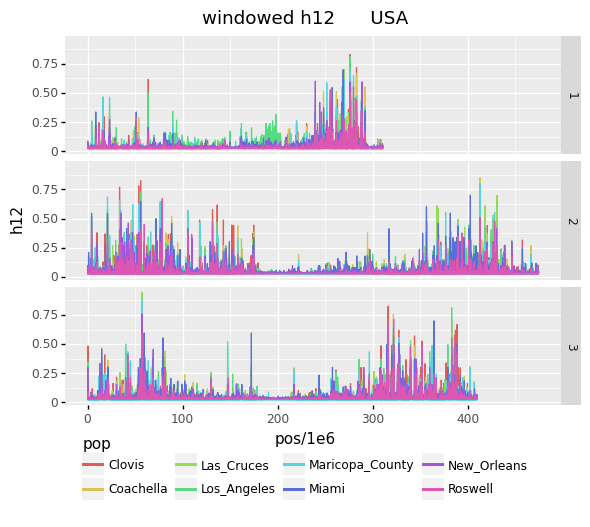

In [14]:
p = ggplot(h12tab,aes(x='pos/1e6',y="h12",color="pop")) + \
  geom_line() + \
  ggtitle("windowed h12      {p1}".format(p1=pop1)) +\
  theme(legend_position='bottom') + facet_grid(("chr","."))
ggsave(plot=p, width=500,height=200,units='mm',filename='h12_250bp_allchroms_thinLD.png', dpi=400)
print(p)
